In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [124]:
df=pd.read_csv("netflix_titles.csv")

##What is the total number of records and columns in the dataset?

In [125]:
#What is the total number of records and columns in the dataset?
row,col=df.shape
print(f"Number of rows is: {row}")
print(f"Number of columns is: {col}")

Number of rows is: 8807
Number of columns is: 12


Answer:
The dataset contains 8807 records and 12 columns.

##What are the data types of each column?

In [126]:
print(df.dtypes)

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


Answer:
Most columns in the dataset are of 'object' data type, indicating categorical or textual data (e.g., title, director, cast, country, rating).   
The 'release_year' column is of integer type (int64), representing numerical year values.

##How many missing values are present in each column?

In [127]:
print(df.isnull().sum())
print("Total Misising values:",df.isnull().sum().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
Total Misising values: 4307


Answer:
The dataset contains a total of 4307 missing values.

The columns with missing values are:
- director: 2634 missing values
- cast: 825 missing values
- country: 831 missing values
- date_added: 10 missing values
- rating: 4 missing values
- duration: 3 missing values

These columns require data cleaning.

##Which columns have missing values and how did you handle them?

In [129]:
df=df.dropna(subset=["date_added"])
df=df.fillna("Not Available")

Answer: As there is approx 4307 missing values, using .dropna() will be not appropriate a huge chunk of data (many rows) will be deleted, instead we use .fill() to replace the missing values with "Not Available" for categorical data like "director","cast","country","rating" and "duration".

But for "date_added" we have only 10 missing values so we can drop them.

##Convert the date_added column into proper datetime format

In [130]:
df["date_added"]=pd.to_datetime(df["date_added"].str.strip())

In [131]:
df["Month_added"]=df["date_added"].dt.month_name()
df["Month_number"]=df["date_added"].dt.month
df["Year_added"]=df["date_added"].dt.year
df["Day"]=df["date_added"].dt.day

Answer:
The 'date_added' column was originally in string format, so it was converted into datetime format using the pandas to_datetime() function after removing any extra spaces.

After conversion, new features were extracted from the column, including:
- Month name
- Month number
- Year
- Day

These new features help in performing time-based analysis more effectively.

##What is the distribution of Movies vs TV Shows?

Text(0, 0.5, 'Number of Movies/TV Shows')

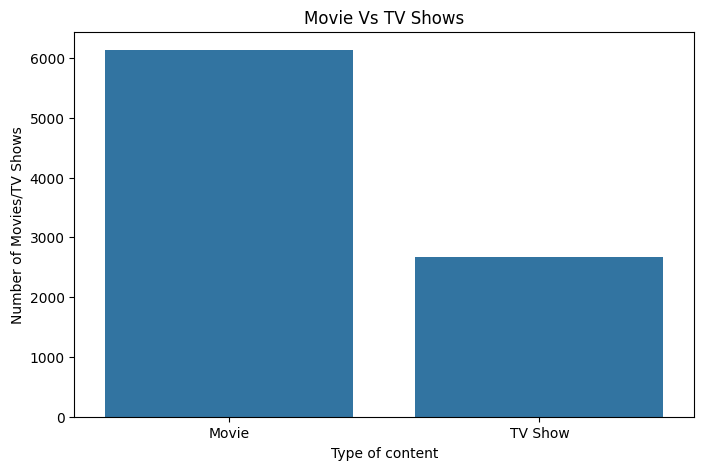

In [132]:
plt.figure(figsize=(8,5))
sns.countplot(x="type",data=df)
plt.title("Movie Vs TV Shows")
plt.xlabel("Type of content")
plt.ylabel("Number of Movies/TV Shows")

Answer: A countplot was used to visualize the distribution of Movies and TV Shows, as the 'type' column is categorical.
From the plot, we can see that the number of movies is way more than TV shows

Conclusion: Movies dominate Netflix content, indicating a strategic focus on standalone content over episodic formats.

##Which are the top 10 most common genres on Netflix and plot a bar chart and analyze?

As one movie can be of multiple genre, we will exapnd the genre column i.e "listed_in"

Genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


Text(0, 0.5, 'Genre')

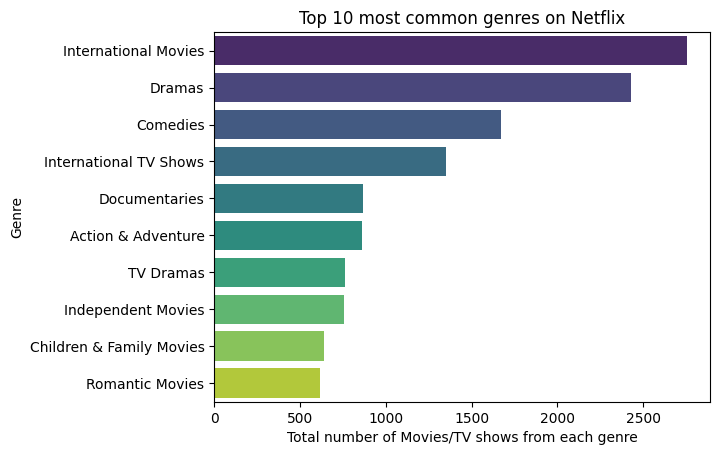

In [135]:
df_genre=df.copy()
df_genre["Genre"]=df_genre["listed_in"].str.split(",")
df_genre=df_genre.explode("Genre")
df_genre=df_genre.dropna(subset=["Genre"])
df_genre["Genre"]=df_genre["Genre"].astype(str).str.strip()

#Now finding the top 10 most common genre
a=df_genre["Genre"].value_counts().head(10)
print(a)

sns.barplot(x=a.values,y=a.index,palette="viridis")
plt.title("Top 10 most common genres on Netflix")
plt.xlabel("Total number of Movies/TV shows from each genre")
plt.ylabel("Genre")


Answer:
The 'listed_in' column contains multiple genres for each entry, so it was first split and expanded using the explode() function to analyze each genre individually.

From the bar chart, it is observed that "International Movies" is the most common genre on Netflix, followed by other genres like Drama and Comedies.

##Which countries produce the most content on Netflix?

Countries
United States     3684
India             1046
United Kingdom     805
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


Text(0, 0.5, 'Countries')

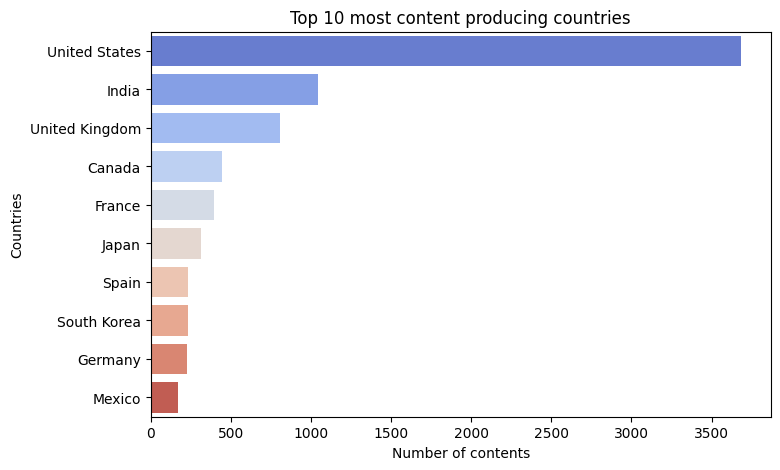

In [137]:
df_country=df.copy()
df_country = df_country[df_country["country"] != "Not Available"]
df_country["Countries"]=df_country["country"].str.split(",")
df_country=df_country.explode("Countries")
df_country=df_country.dropna(subset=["Countries"]) #drop all the missing countries column
df_country["Countries"]=df_country["Countries"].astype(str).str.strip()

a=df_country["Countries"].value_counts().head(10)
print(a)
plt.figure(figsize=(8,5))
sns.barplot(x=a.values,y=a.index,palette="coolwarm")
plt.title("Top 10 most content producing countries")
plt.xlabel("Number of contents")
plt.ylabel("Countries")

Answer:
A copy of the original dataframe was created to avoid modifying the original data.Rows where the 'country' column had the value "Not Available" were removed, as they represent missing or invalid data

After this, the "country" column contains multiple country for each entry, so it was first split and expanded using the explode() function to analyze each country individually.

From the barchart, it is observed that United States produces the most number of content followed by India and United Kingdom.

##What is the most common content rating?

In [138]:
df_content=df.copy()
df_content=df_content[(df_content["rating"]!="Not Available")]
a=df_content["rating"].value_counts()
print("Most common content rating is:",a.idxmax())

Most common content rating is: TV-MA


Answer: A copy of original dataframe is created to avoid modifying the original data. Rows where the "rating" column had value "Not Available" were removed, as they represent missing or invalid data.

The most common content rating on Netflix is TV-MA.

##How has content addition changed over the years?

Year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


Text(49.597222222222214, 0.5, 'Number of content')

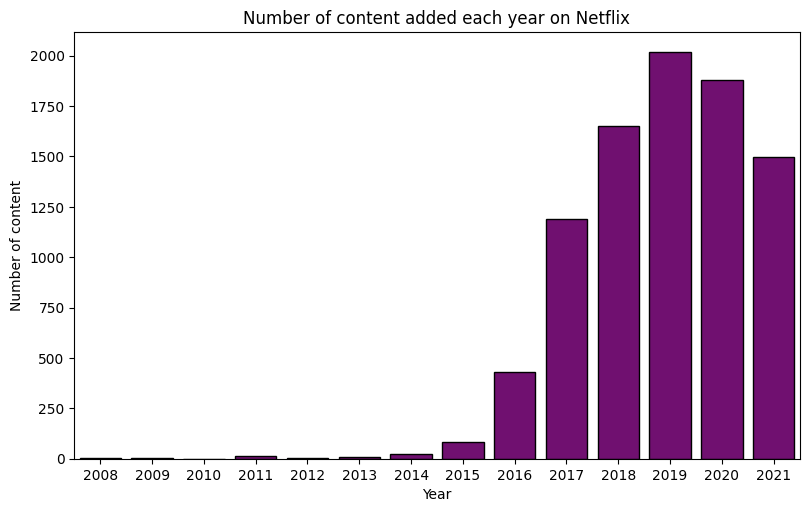

In [142]:
a=df["Year_added"].value_counts().sort_index()
print(a)
plt.figure(figsize=(8,5))
sns.barplot(x=a.index,y=a.values,color="purple",edgecolor="black")
plt.tight_layout()
plt.title("Number of content added each year on Netflix")
plt.xlabel("Year")
plt.ylabel("Number of content")

Answer:
From the bar chart, it is observed that there was a gradual increase in content added to Netflix from 2008 to 2016. After that, there was a rapid growth in content additions, reaching a peak around 2019, followed by a slight decline.

##Which year had the highest number of content additions?

In [143]:
a=df["Year_added"].value_counts()
print("Year:",a.idxmax())
print("Number of contents added:",a.max())

Year: 2019
Number of contents added: 2016


Answer:
The highest number of content additions occurred in the year 2019, with 2016 titles added.

##Which month sees the highest content addition?

In [144]:
a=df["Month_added"].value_counts()
month=a.idxmax()
cont_add=a.max()
print("Month with highest number of content addition:",month)
print("Total number of content added:",cont_add)

Month with highest number of content addition: July
Total number of content added: 827


Answer: The highest number of content additions occurred in July, with 827 titles added.

##What is the distribution of release years of content?

Text(0, 0.5, 'Number of contents')

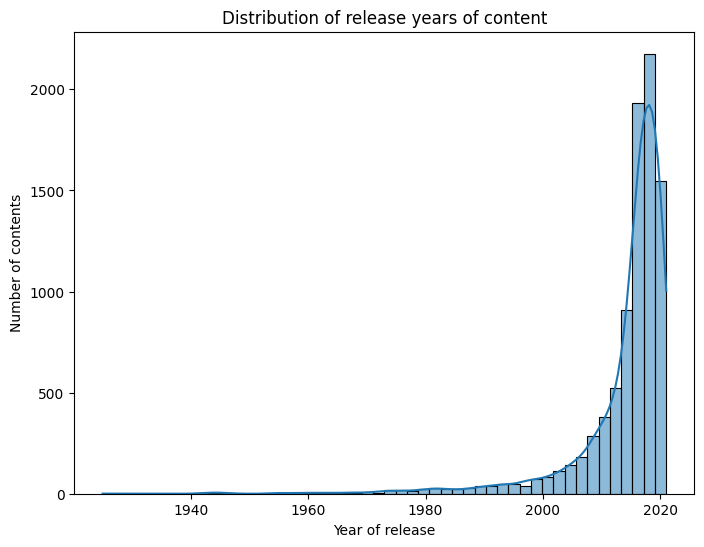

In [147]:
plt.figure(figsize=(8,6))
sns.histplot(x="release_year",bins=50,data=df,kde=True)
plt.title("Distribution of release years of content")
plt.xlabel("Year of release")
plt.ylabel("Number of contents")


Answer:
The distribution of release years shows that most content available on Netflix is from recent years, particularly after 2000. There is a noticeable increase in content released after 2010.

##Who are the most frequent directors on Netflix?

In [148]:
df_director=df.copy()
df_director=df_director[(df_director["director"]!="Not Available")]
df_director["director"]=df_director["director"].str.split(",")
df_director=df_director.explode("director")
df_director=df_director.dropna(subset=["director"])
df_director["director"]=df_director["director"].astype(str).str.strip()

a=df_director["director"].value_counts().head(10)
print(a)

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Martin Scorsese        12
Youssef Chahine        12
Jay Chapman            12
Name: count, dtype: int64


Answer: A copy of the original dataframe was created to avoid modifying the original data. Rows where the 'director' column had the value "Not Available" were removed, as they represent missing or invalid data.

The 'director' column contains multiple directors for some movies, so it was first split and expanded using the explode() function to analyze each director individually.

The top 10 frequent directors on Netflix are:

Rajiv Chilaka: 22

Jan Suter: 21

Raúl Campos: 19

Suhas Kadav: 16

Marcus Raboy: 16

Jay Karas: 15

Cathy Garcia-Molina: 13

Martin Scorsese: 12

Youssef Chahine: 12

Jay Chapman: 12

##Which actors appear most frequently?

In [149]:
df_actor=df.copy()
df_actor=df_actor.loc[(df_actor["cast"]!="Not Available")]

df_actor["cast"]=df_actor["cast"].str.split(",")
df_actor=df_actor.explode("cast")
df_actor=df_actor.dropna(subset=["cast"])
df_actor["cast"]=df_actor["cast"].astype(str).str.strip()

a=df_actor["cast"].value_counts().head(10)
print(a)

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Takahiro Sakurai    32
Naseeruddin Shah    32
Rupa Bhimani        31
Om Puri             30
Akshay Kumar        30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64


Answer: A copy of the original dataframe is created to avoid modifying the original data.

Rows where "cast" column had the value "Not Available" were removed as they represent missing or invalid data.
The "cast" column contains multiple names for every movie, so it was first split and expanded using the explode() function to analyze each actor individually.

The top 10 frequent actors on Netflix are:
Anupam Kher:	43

Shah Rukh Khan:	35

Julie Tejwani:	33

Takahiro Sakurai:	32

Naseeruddin Shah:	32

Rupa Bhimani:	31

Om Puri:	30

Akshay Kumar:	30

Yuki Kaji:	29

Amitabh Bachchan:	28


##Is there any relationship between content type and rating?

Text(24.722222222222214, 0.5, 'Rating')

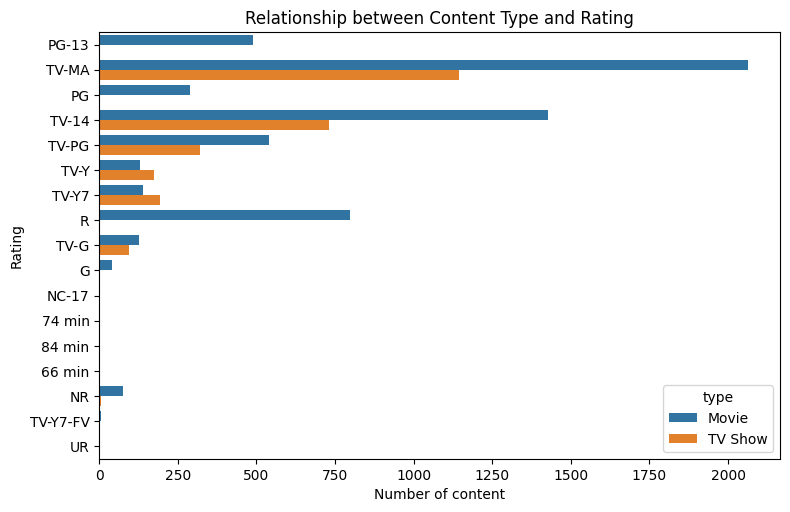

In [153]:
df1=df.copy()
df1=df1.loc[(df1["rating"]!="Not Available")]
plt.figure(figsize=(8,5))
sns.countplot(y="rating",hue="type",data=df1)
plt.tight_layout()
plt.title("Relationship between Content Type and Rating")
plt.xlabel("Number of content")
plt.ylabel("Rating")

Answer:
A countplot with 'rating' on the y-axis and 'type' as hue was used to analyze the relationship between content type and rating.

From the plot, it is observed that certain ratings such as TV-MA and TV-14 are more common in both Movies and TV Shows. However, Movies tend to dominate across most rating categories, especially in mature ratings.

This indicates that both Movies and TV Shows on Netflix are largely targeted toward mature audiences, with Movies being more prevalent overall.

##Which genre is most common for Movies vs TV Shows?

Text(-90.15277777777779, 0.5, 'Genres')

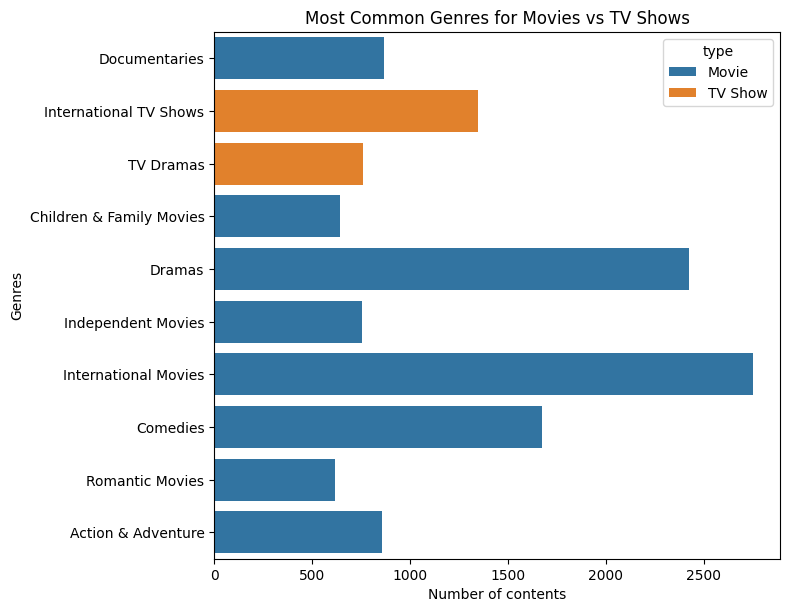

In [163]:
df_genre=df.copy()
df_genre=df_genre.loc[(df_genre["listed_in"]!="Not Available")]
df_genre["listed_in"]=df_genre["listed_in"].str.split(",")
df_genre=df_genre.explode("listed_in")
df_genre=df_genre.dropna(subset=["listed_in"])
df_genre["listed_in"]=df_genre["listed_in"].astype(str).str.strip()

top10=df_genre["listed_in"].value_counts().head(10).index
df_genre_filtered=df_genre.loc[df_genre["listed_in"].isin(top10)]

plt.figure(figsize=(8,6))
sns.countplot(y="listed_in",hue="type",data=df_genre_filtered)
plt.tight_layout()
plt.title("Most Common Genres for Movies vs TV Shows")
plt.xlabel("Number of contents")
plt.ylabel("Genres")

Answer:
The 'listed_in' column was split and expanded to analyze each genre individually. The top 10 most common genres were selected to ensure a clear and meaningful comparison.

A countplot was used with 'type' as hue to compare Movies and TV Shows across genres.

From the plot, it is observed that "International Movies" is the most common genre among Movies, while "International TV Shows" is the most common genre among TV Shows.

Insight:
This indicates that Netflix has a strong focus on international content across both Movies and TV Shows, reflecting its global audience and content strategy.

##How has Netflix expanded globally over time?

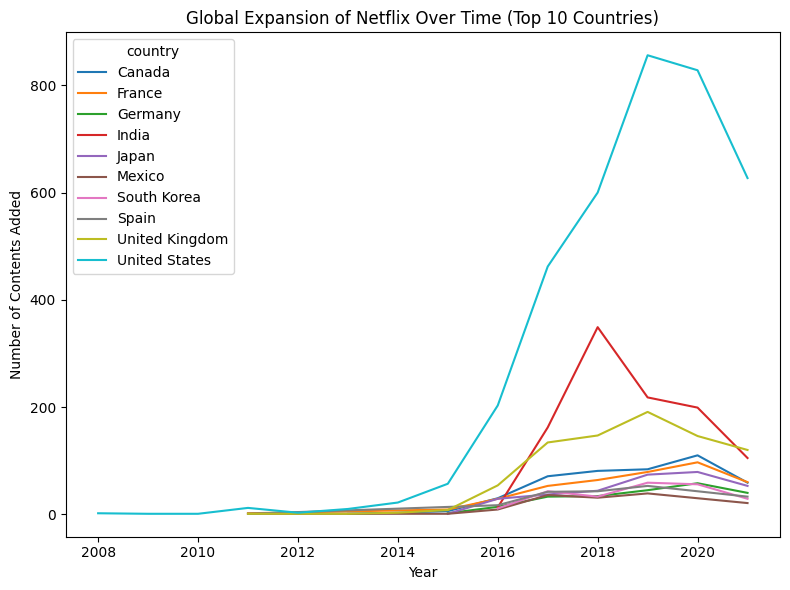

In [161]:
df_country2=df.copy()
df_country2=df_country2.loc[(df_country2["country"]!="Not Available")]
df_country2["country"]=df_country2["country"].str.split(",")
df_country2=df_country2.explode("country")
df_country2=df_country2.dropna(subset=["country"])
df_country2["country"]=df_country2["country"].astype(str).str.strip()

top10 = df_country2["country"].value_counts().head(10).index
df_country2 = df_country2[df_country2["country"].isin(top10)]
# Group by country and year
grouped = df_country2.groupby(["country", "Year_added"]).size().reset_index(name="count")

# Plot
plt.figure(figsize=(8,6))
sns.lineplot(data=grouped, x="Year_added", y="count", hue="country")
plt.title("Global Expansion of Netflix Over Time (Top 10 Countries)")
plt.xlabel("Year")
plt.ylabel("Number of Contents Added")
plt.tight_layout()

#Answer:
To analyze Netflix's global expansion, the 'country' column was split and expanded to consider each country individually. The data was then analyzed across different years using the 'Year_added' column.

From the analysis, it is observed that content production has increased over time across multiple countries, especially in top contributing countries like the United States, India, and the United Kingdom.

This indicates that Netflix has expanded globally by increasing content availability from different countries over the years.

##Final Insights

1. Movies dominate Netflix content, indicating that the platform focuses more on movie production compared to TV Shows.

2. "International Movies" and "International TV Shows" are among the most common genres, highlighting Netflix's strong global content strategy.

3. The United States contributes the highest number of titles, followed by countries like India and the United Kingdom, showing a diverse international presence.
4. Content additions increased significantly after 2015, reaching a peak around 2019, which reflects Netflix’s rapid expansion during this period.

5. The majority of content available on Netflix is from recent years, especially after 2000, showing a focus on modern content.

6. The most common rating is TV-MA, indicating that a large portion of Netflix content is targeted toward mature audiences.

##Conclusion

Conclusion:

This project analyzed Netflix's content dataset to understand patterns in content distribution, genres, countries, and trends over time. The analysis revealed that Netflix has significantly expanded its content library, especially after 2015, with a strong focus on international and modern content.

The platform is dominated by movies and caters largely to mature audiences. Additionally, the presence of content from multiple countries highlights Netflix’s global reach and strategy.

Overall, this analysis demonstrates how data can be used to uncover meaningful insights about content trends and platform growth.